In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold

In [2]:
dior = pd.read_csv("dior_clean.csv")
dior.corr(numeric_only=True)["is_return"].sort_values(ascending=False) 
#If there is an irealistic correlation, it would indicate some dataleakage (That is why I got rid off timespan_days_less_than_10)

is_return                                 1.000000
product_subcategory_Apparel (Clothing)    0.101060
quantity_0.0                              0.089422
product_subcategory_Footwear              0.082679
sales_band_2000_4000                      0.054289
                                            ...   
product_subcategory_Home & Lifestyle     -0.074212
csc commercial gestures                  -0.093344
sales_band_0_500                         -0.110355
is_ltsourcing                            -0.184140
timespan_days_less_than_10               -0.983972
Name: is_return, Length: 112, dtype: float64

In [3]:
#We prepare the data, split it into train and test and prepare the cross validation
X, y = dior.drop(columns=["order number", "order status", "is_return", "timespan_days_less_than_10"]), dior["is_return"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                            shuffle=True, random_state=72)
cv = KFold(n_splits=3, shuffle=True, random_state=72)

In [4]:
#Test 1: Use Naive Bayes
nbc = GaussianNB()

nbc.fit(X_train, y_train)

y_pred_train_bayes = nbc.predict(X_train)
y_pred_test_bayes = nbc.predict(X_test)
p_nbc_test = nbc.predict_proba(X_test)[:, 1]

print(f"Accuracy test Bayes: {accuracy_score(y_test, y_pred_test_bayes):.3f}")
print(f"Accuracy train Bayes: {accuracy_score(y_train, y_pred_train_bayes):.3f}")
#The results seem to be very bad. This can be explained that 
# Explanation: Naive Bayes performs poorly here because many features (like the US states) are highly correlated, which breaks the model's independence assumption.

Accuracy test Bayes: 0.423
Accuracy train Bayes: 0.420


In [ ]:
#Test 2: Use Classifier which always predicts the most common class

# What is the most common class?
display(  round( y_train.value_counts()/dior.shape[0], 3   ))

# So we predict always zero for the "most-common" classifier
y_pred_train_mc = np.zeros(len(y_train))
y_pred_test_mc = np.zeros(len(y_test))


print(f"Accuracy test Most Common: {accuracy_score(y_test, y_pred_test_mc):.3f}")
print(f"Accuracy train Most Common: {accuracy_score(y_train, y_pred_train_mc):.3f}")
#It points out how bad our naïve Bayes classifier ist

#The high accuracy can also be explained by the disproportion between the two classes

is_return
0    0.478
1    0.222
Name: count, dtype: float64

Accuracy test Most Common: 0.680
Accuracy train Most Common: 0.683


In [ ]:
#Test 3: Use Logistic Regression
lrc = LogisticRegression(max_iter=5000, penalty = None)

lrc.fit(X_train, y_train)

y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_lrc = lrc.predict(X_test)
p_lrc_test = lrc.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg: {accuracy_score(y_test, y_pred_test_lrc):.3f}")
print(f"Accuracy train Logreg: {accuracy_score(y_train, y_pred_train_lrc):.3f}")

# It manages to converge with a not too bad accuracy performance

# Here the model tries to minimize the log-loss function using gradient descent; 
# that is why we have to decide how many iterations we want

Accuracy test Logreg: 0.697
Accuracy train Logreg: 0.702


In [ ]:
# Let us see if it is necessary to adapt the threshold as there are clearly more products that are not returned then products that are returned
dior["is_return"].value_counts()

p_train = lrc.predict_proba(X_train)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)

best_threshold = 0.5
best_accuracy = -1

for t in thresholds:
    y_pred_train_thresh = (p_train >= t).astype(int)
    accuracy = accuracy_score(y_train, y_pred_train_thresh)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = t

print(f"Best accuracy: {best_accuracy:.3f}")
print(f"Best Threshold: {best_threshold:.3f}")
# There seems to have no sense adapting the threshold

Best accuracy: 0.702
Best Threshold: 0.500


In [ ]:
#Test 4: Use Logistic Regression with Lasso penalization as we could notice some overfitting in the logistic regression
lrc_lasso = LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=72)

lrc_lasso.fit(X_train, y_train)

y_pred_train_lrc_lasso = lrc_lasso.predict(X_train)
y_pred_test_lrc_lasso = lrc_lasso.predict(X_test)
p_lrc_lasso_test = lrc_lasso.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg (lasso): {accuracy_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Accuracy train Logreg (lasso): {accuracy_score(y_train, y_pred_train_lrc_lasso):.3f}")
#It does not make a huge difference but the model still performs better in the test set

# We have to change the solver into Liblinear because the estimator LogisticRegression uses per default the "lbfgs" solver
# This solver works only if we assume that the function is perfectly differenciable
# As it is not the case because of the lasso penalty we add (absolute value)
#We have to change the solver into liblinear (as this solver works with hazard; we fix a random state)

Accuracy test Logreg (lasso): 0.697
Accuracy train Logreg (lasso): 0.702


In [9]:
#Test 5: Use Logistic Regression with Ridge penalization to see if it works better than Lasso
lrc_ridge = LogisticRegression(penalty="l2", max_iter=5000)

lrc_ridge.fit(X_train, y_train)

y_pred_train_lrc_ridge = lrc_ridge.predict(X_train)
y_pred_test_lrc_ridge = lrc_ridge.predict(X_test)
p_lrc_ridge_test = lrc_ridge.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg (ridge): {accuracy_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Accuracy train Logreg (ridge): {accuracy_score(y_train, y_pred_train_lrc_ridge):.3f}")
# That is not the case; Lasso regularization gives the best accuracy

Accuracy test Logreg (ridge): 0.696
Accuracy train Logreg (ridge): 0.702


In [ ]:
#Test 6: Neural Network
from sklearn.neural_network import MLPClassifier
nnet = MLPClassifier(hidden_layer_sizes=(8, 16, 8),# we decide to fix 8 neurones in input and output layer and 16 neurones in hidden layer
                     learning_rate_init=0.003,#the size of the step in the stochastic gradient descent
                     activation="relu",#let us use the relu function as an activation function
                     solver="sgd", # We choose as a solver the stochastic gradient deschent
                     alpha=0.001,#ridge penalty
                     batch_size=32, #necessary if we make a stochastic gradient descent
                     max_iter=500, #number of iterations util it stops
                     random_state = 72)
nnet.fit(X_train, y_train)

y_pred_train_neuron = nnet.predict(X_train)
y_pred_test_neuron = nnet.predict(X_test)

print(f"Accuracy test Neural Network: {accuracy_score(y_test, y_pred_test_neuron):.3f}")
print(f"Accuracy train Neural Network: {accuracy_score(y_train, y_pred_train_neuron):.3f}")

#The model seems to perform  a bit better than logistic regression without regularization; let us tune the hyperparameter using Cross Validation

# The neural network uses the same core principle as logistic regression:
# it minimizes the log-loss function using gradient descent.
# However, the key difference is that stacking several activation functions introduces non-linearity.
# Because of this added non-linearity, the overall loss function becomes non-convex,
# which is why stochastic gradient descent is used in order to avoid falling in a local minimum.
# This is also why fixing a random_state is important to ensure reproducible results

Accuracy test Neural Network: 0.697
Accuracy train Neural Network: 0.708


In [ ]:
#Test 7: Neural Network with tuned Hyperparameters using cross validation
param_dist = {
    "hidden_layer_sizes": [(16,), (16, 16), (8, 16, 8), (16, 16, 16)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.003, 0.008],
    "solver": ["adam", "sgd"]
}

search_neuron = RandomizedSearchCV(
    MLPClassifier(max_iter=500, batch_size=32, activation="relu", random_state = 72),
    param_distributions=param_dist,
    scoring="accuracy",#that is what we want to minimize
    cv=cv, random_state = 72# to ensure reproducibilty without this different folds for the cv will be used each time
)
search_neuron.fit(X_train, y_train)
best_model_neuron = search_neuron.best_estimator_
y_pred_test_neuron_hyp = best_model_neuron.predict(X_test)
y_pred_train_neuron_hyp = best_model_neuron.predict (X_train)
p_neuron_hyp_test = best_model_neuron.predict_proba(X_test)[:, 1]

print(f"Accuracy test Neural Network with tuned hyperparameters: {accuracy_score(y_test, y_pred_test_neuron_hyp):.3f}")
print(f"Accuracy train Neural Network with tuned hyperparameters: {accuracy_score(y_train, y_pred_train_neuron_hyp):.3f}")

# The results are better but not extremely convincing.
# The slightly lower training accuracy can be explained by the fact that 
# RandomizedSearchCV optimizes the average accuracy across CV folds, 
# not the accuracy on the entire training set. 
# As a result, the selected model generalizes better to unseen data 
# but may perform slightly worse on the full training data.

Accuracy test Neural Network with tuned hyperparameters: 0.698
Accuracy train Neural Network with tuned hyperparameters: 0.705


In [ ]:
#Test 8: Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, #number of trees 
                            max_depth=20, #also bad for overfitting
                            min_samples_split=2, 
                            min_samples_leaf=1, #explains the overfitting (the model learns unnecessary noise); only one observation in a leaf is possible 
                            max_features="sqrt", 
                            random_state=72 ) # to ensure reproducibility because of the bootstrap sampling
rf.fit(X_train, y_train) 

y_pred_test_rf = rf.predict(X_test) 
y_pred_train_rf = rf.predict(X_train)
p_rf_test = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy test Random Forest: {accuracy_score(y_test, y_pred_test_rf):.3f}")
print(f"Accuracy train Random Forest: {accuracy_score(y_train, y_pred_train_rf):.3f}")
#The results are the best until now

# Random Forest is an "optimized" form of bagging.
# A main weakness of decision trees is that they tend to easily overfit.
# Bagging addresses this by: 
#   (1) creating several random bootstrap samples of the dataset (drawn with replacement),
#   (2) training one tree on each sample,
#   (3) averaging the predictions.
# Random Forest builds on this idea but adds an important improvement:
#   at each split, only a random subset of the features is considered for ex. (max_features="sqrt").
# This reduces the correlation between the trees and makes them as different as possible,
# which further reduces overfitting and improves generalization

Accuracy test Random Forest: 0.700
Accuracy train Random Forest: 0.716


In [ ]:
#Test 9: Random forest with tuned hyperparameters using cross-validation
from sklearn.ensemble import RandomForestClassifier

param_distributions = {
    "n_estimators": [150, 300],
    "min_samples_split": [2, 3],
    "max_depth": [5, 10, 20],           
    "min_samples_leaf": [1, 5, 50, 150],
    "max_features": ["sqrt"]}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=72),
    param_distributions=param_distributions,
    scoring="accuracy",
    cv=cv,
    refit=True,   # refit best on all training data
    return_train_score=True, random_state = 72)



search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred_test_rf_hyp = best_model.predict(X_test)
y_pred_train_rf_hyp = best_model.predict(X_train)
p_rf_hyp_test = search.predict_proba(X_test)[:, 1]
print(f"Accuracy test Random Forest with hyperparameter tunning: {accuracy_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Accuracy train Random Forest with hyperparameter tunning: {accuracy_score(y_train, y_pred_train_rf_hyp):.3f}")

Accuracy test Random Forest with hyperparameter tunning: 0.699
Accuracy train Random Forest with hyperparameter tunning: 0.711


In [ ]:
#Test 10: Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_leaf_nodes=30,#maximum number of leaves
    min_samples_leaf=20,#minimum number of observations in a leaf
    early_stopping=True,
    n_iter_no_change=20,#to decide the early stopping
    validation_fraction=0.2,#to decide the early stopping
    random_state=72)#to ensure reproducibility
gb.fit(X_train, y_train)
y_pred_test_boosting = gb.predict(X_test)
y_pred_train_boosting = gb.predict(X_train)
p_boosting_test = gb.predict_proba(X_test)[:, 1]
print(f"Accuracy test Boosting: {accuracy_score(y_test, y_pred_test_boosting):.3f}")
print(f"Accuracy test Boosting: {accuracy_score(y_train, y_pred_train_boosting):.3f}")

# In boosting, the trees are built sequentially.
# Each new tree is trained to correct the errors made by the previous ones.
# The larger the learning rate, the greater the risk of overfitting,
# because each tree has a stronger influence on the final model (especially the last one)

Accuracy test Boosting: 0.699
Accuracy test Boosting: 0.707


In [ ]:
#Test 11: Boosting with tuned hyperparameters using cross validation

param_dist = {
    "learning_rate": [0.01, 0.05],
    "max_leaf_nodes": [10, 20, 30],
    "min_samples_leaf": [20, 40. 50],
    "n_iter_no_change": [10, 20, 30]
}

search_boosting = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.2,
        random_state=72
    ),
    param_distributions=param_dist,              
    scoring="accuracy",
    cv=cv,
    random_state=72
)
search_boosting.fit(X_train, y_train)
best_model_boosting = search_boosting.best_estimator_
y_pred_test_boosting_hyp = best_model_boosting.predict(X_test)
y_pred_train_boosting_hyp = best_model_boosting.predict (X_train)
p_boosting_hyp_test = best_model_boosting.predict_proba(X_test)[:, 1]

print(f"Accuracy test Boosting with tuned hyperparameters: {accuracy_score(y_test, y_pred_test_boosting_hyp):.3f}")
print(f"Accuracy train Boosting with tuned hyperparameters: {accuracy_score(y_train, y_pred_train_boosting_hyp):.3f}")
#The results indicate that a peak has been reachen with an accuracy of 0.7

Accuracy test Boosting with tuned hyperparameters: 0.700
Accuracy train Boosting with tuned hyperparameters: 0.707


In [ ]:
from sklearn.metrics import accuracy_score

print(f"Accuracy test Bayes: {accuracy_score(y_test, y_pred_test_bayes):.3f}")
print(f"Accuracy test Most Common: {accuracy_score(y_test, y_pred_test_mc):.3f}")
print(f"Accuracy test Logreg: {accuracy_score(y_test, y_pred_test_lrc):.3f}")
print(f"Accuracy test Logreg (lasso): {accuracy_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Accuracy test Logreg (ridge): {accuracy_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Accuracy test Neural Network with hyperparameter tuning: {accuracy_score(y_test, y_pred_test_neuron_hyp):.3f}")
print(f"Accuracy test Random Forest with hyperparameter tuning: {accuracy_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Accuracy test Boosting with hyperparameter tuning: {accuracy_score(y_test, y_pred_test_boosting_hyp):.3f}")

#Accuracy measures: (TP + TN)/(TP + TN + FP + FN)

Accuracy test Bayes: 0.423
Accuracy test Most Common: 0.680
Accuracy test Logreg: 0.697
Accuracy test Logreg (lasso): 0.697
Accuracy test Logreg (ridge): 0.696
Accuracy test Neural Network with hyperparameter tuning: 0.698
Accuracy test Random Forest with hyperparameter tuning: 0.699
Accuracy test Boosting with hyperparameter tuning: 0.700


In [ ]:
from sklearn.metrics import recall_score 

print(f"Recall test Bayes: {recall_score(y_test, y_pred_test_bayes):.3f}")
print(f"Recall test Most Common: {recall_score(y_test, y_pred_test_mc):.3f}")
print(f"Recall test Logreg: {recall_score(y_test, y_pred_test_lrc):.3f}")
print(f"Recall test Logreg (lasso): {recall_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Recall test Logreg (ridge): {recall_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Recall test Neural Network with hyperparameter tuning: {recall_score(y_test, y_pred_test_neuron_hyp):.3f}")
print(f"Recall test Random Forest with hyperparameter tuning: {recall_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Recall test Boosting with hyperparameter tuning: {recall_score(y_test, y_pred_test_boosting_hyp):.3f}")

#Recall measures:(TP/(TP+FN)) --> gooal is to avoid that some positives are undetected

Recall test Bayes: 0.991
Recall test Most Common: 0.000
Recall test Logreg: 0.148
Recall test Logreg (lasso): 0.148
Recall test Logreg (ridge): 0.148
Recall test Neural Network with hyperparameter tuning: 0.165
Recall test Random Forest with hyperparameter tuning: 0.126
Recall test Boosting with hyperparameter tuning: 0.139


In [ ]:
from sklearn.metrics import precision_score

print(f"Precision test Bayes: {precision_score(y_test, y_pred_test_bayes):.3f}")
print(f"Precision test Most Common: {precision_score(y_test, y_pred_test_mc):.3f}")
print(f"Precision test Logreg: {precision_score(y_test, y_pred_test_lrc):.3f}")
print(f"Precision test Logreg (lasso): {precision_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Precision test Logreg (ridge): {precision_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Precision test Neural Network with hyperparameter tuning: {precision_score(y_test, y_pred_test_neuron_hyp):.3f}")
print(f"Precision test Random Forest with hyperparameter tuning: {precision_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Precision test Boosting with hyperparameter tuning: {precision_score(y_test, y_pred_test_boosting_hyp):.3f}")

#Precision measures:(TP/(TP+FP)) --> goal is to minimize the number of false positive

Precision test Bayes: 0.356
Precision test Most Common: 0.000
Precision test Logreg: 0.610
Precision test Logreg (lasso): 0.609
Precision test Logreg (ridge): 0.608
Precision test Neural Network with hyperparameter tuning: 0.605
Precision test Random Forest with hyperparameter tuning: 0.661
Precision test Boosting with hyperparameter tuning: 0.645


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import f1_score 

print(f"F1-score test Bayes: {f1_score(y_test, y_pred_test_bayes):.3f}")
print(f"F1-score test Most Common: {f1_score(y_test, y_pred_test_mc):.3f}")
print(f"F1-score test Logreg: {f1_score(y_test, y_pred_test_lrc):.3f}")
print(f"F1-score test Logreg (lasso): {f1_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"F1-score test Logreg (ridge): {f1_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"F1-score test Neural Network with hyperparameter tuning: {f1_score(y_test, y_pred_test_neuron_hyp):.3f}")
print(f"F1-score test Random Forest with hyperparameter tuning: {f1_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"F1-score test Boosting with hyperparameter tuning: {f1_score(y_test, y_pred_test_boosting_hyp):.3f}")

#F1-score measures: (2 · (Precision · Recall) / (Precision + Recall)) --> goal is to find an equilibrium between Precision and Recall

F1-score test Bayes: 0.524
F1-score test Most Common: 0.000
F1-score test Logreg: 0.238
F1-score test Logreg (lasso): 0.238
F1-score test Logreg (ridge): 0.238
F1-score test Neural Network with hyperparameter tuning: 0.260
F1-score test Random Forest with hyperparameter tuning: 0.211
F1-score test Boosting with hyperparameter tuning: 0.229


In [ ]:
from sklearn.metrics import roc_auc_score 

print(f"ROC score test Bayes: {roc_auc_score(y_test, p_nbc_test):.3f}")
print(f"ROC score test logreg: {roc_auc_score(y_test, p_lrc_test):.3f}")
print(f"ROC score test logreg (Lasso): {roc_auc_score(y_test, p_lrc_lasso_test):.3f}")
print(f"ROC score test logreg (Ridge): {roc_auc_score(y_test, p_lrc_ridge_test):.3f}")
print(f"ROC score test Neural Network with hyperparameter tuning: {roc_auc_score(y_test, p_neuron_hyp_test):.3f}")
print(f"ROC score test Random Forest with hyperparameter tuning: {roc_auc_score(y_test, p_rf_hyp_test):.3f}")
print(f"ROC score test Boosting with hyperparameter tuning: {roc_auc_score(y_test, p_boosting_hyp_test):.3f}")

#ROC measures the capacity of the model to best distinguish between the classes using the true positive rate --> recall(TP/(TP+FN))and the false positive rate (FP / (FP + TN)) across all possible thresholds 

ROC score test Bayes: 0.575
ROC score test logreg: 0.694
ROC score test logreg (Lasso): 0.694
ROC score test logreg (Ridge): 0.694
ROC score test Neural Network with hyperparameter tuning: 0.696
ROC score test Random Forest with hyperparameter tuning: 0.706
ROC score test Boosting with hyperparameter tuning: 0.702


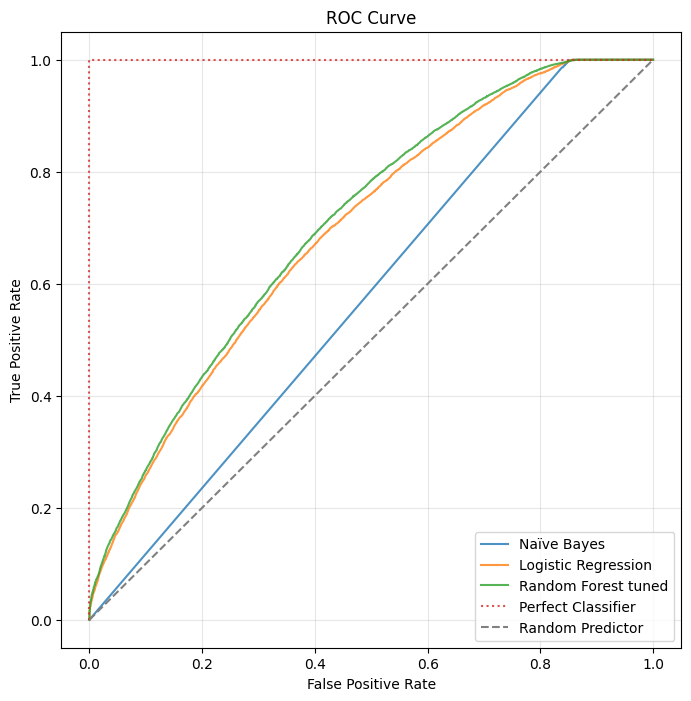

In [12]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 8))


fpr, tpr, thresholds = roc_curve(y_test, p_nbc_test)
ax.plot(fpr, tpr, label="Naïve Bayes", alpha=0.8)

fpr, tpr, thresholds = roc_curve(y_test, p_lrc_test)
ax.plot(fpr, tpr, label="Logistic Regression", alpha=0.8)

fpr, tpr, thresholds = roc_curve(y_test, p_rf_hyp_test)
ax.plot(fpr, tpr, label="Random Forest tuned", alpha=0.8)


ax.plot([0, 0, 1], [0, 1, 1], label="Perfect Classifier", linestyle=":", alpha=0.8)

ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random Predictor")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.grid(alpha=.3)

Text(0.5, 1.0, 'Most Common')

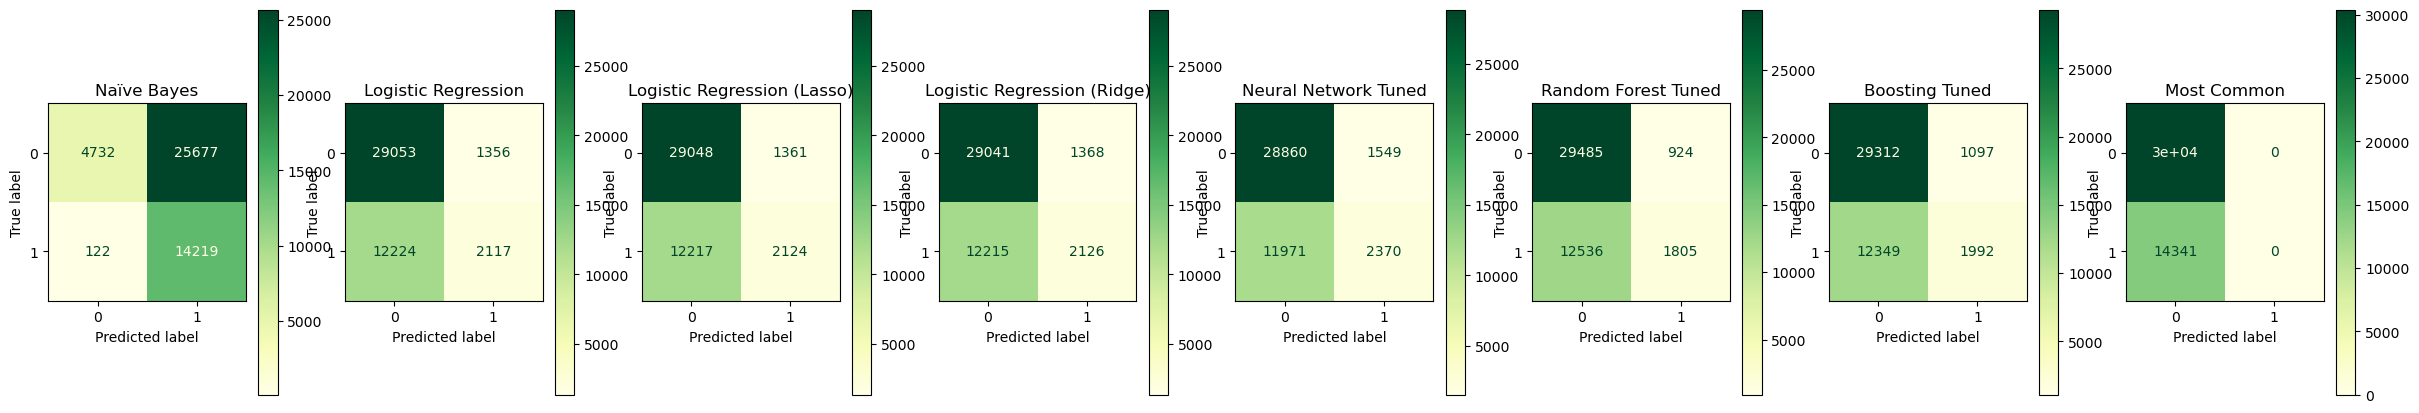

In [21]:
from sklearn.metrics import confusion_matrix

cm_bayes = confusion_matrix(y_test, y_pred_test_bayes)
cm_mc = confusion_matrix(y_test, y_pred_test_mc)
cm_logreg = confusion_matrix(y_test, y_pred_test_lrc)
cm_lasso = confusion_matrix(y_test, y_pred_test_lrc_lasso)
cm_ridge = confusion_matrix(y_test, y_pred_test_lrc_ridge)
cm_neural_hyp = confusion_matrix(y_test, y_pred_test_neuron_hyp)
cm_rf_hyp = confusion_matrix(y_test, y_pred_test_rf_hyp)
cm_boosting_hyp = confusion_matrix(y_test, y_pred_test_boosting_hyp)

from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(1, 8, figsize=(30, 5))


ConfusionMatrixDisplay(cm_bayes).plot(ax=ax[0], cmap=plt.cm.YlGn)
ax[0].set_title("Naïve Bayes")


ConfusionMatrixDisplay(cm_logreg).plot(ax=ax[1], cmap=plt.cm.YlGn)
ax[1].set_title("Logistic Regression")


ConfusionMatrixDisplay(cm_lasso).plot(ax=ax[2], cmap=plt.cm.YlGn)
ax[2].set_title("Logistic Regression (Lasso)")


ConfusionMatrixDisplay(cm_ridge).plot(ax=ax[3], cmap=plt.cm.YlGn)
ax[3].set_title("Logistic Regression (Ridge)")


ConfusionMatrixDisplay(cm_neural_hyp).plot(ax=ax[4], cmap=plt.cm.YlGn)
ax[4].set_title("Neural Network Tuned")

ConfusionMatrixDisplay(cm_rf_hyp).plot(ax=ax[5], cmap=plt.cm.YlGn)
ax[5].set_title("Random Forest Tuned")


ConfusionMatrixDisplay(cm_boosting_hyp).plot(ax=ax[6], cmap=plt.cm.YlGn)
ax[6].set_title("Boosting Tuned")


ConfusionMatrixDisplay(cm_mc).plot(ax=ax[7], cmap=plt.cm.YlGn)
ax[7].set_title("Most Common")

Text(0.5, 1.0, 'Boosting Tuned')

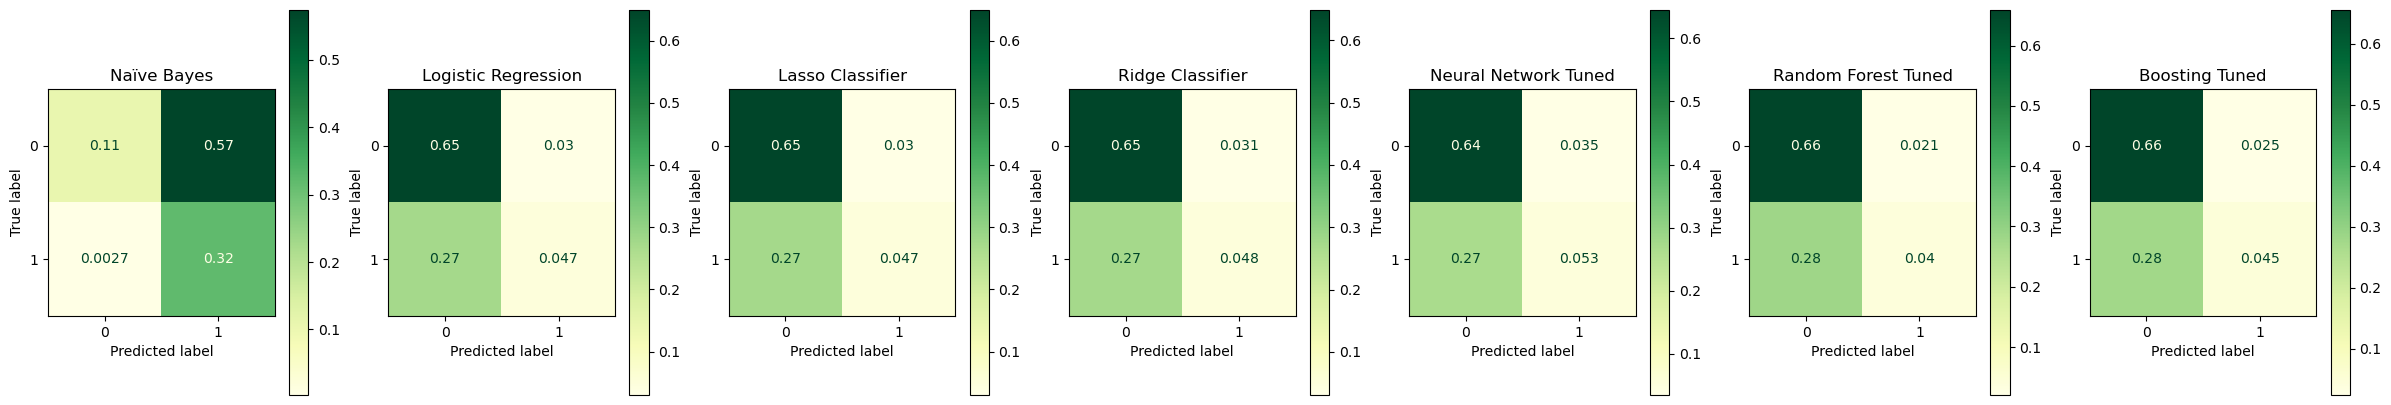

In [22]:
fig, ax = plt.subplots(1, 7, figsize=(30, 5))


ConfusionMatrixDisplay.from_estimator(
    nbc, X_test, y_test,
    normalize='all',      
    cmap=plt.cm.YlGn,
    ax=ax[0]
)
ax[0].set_title("Naïve Bayes")

ConfusionMatrixDisplay.from_estimator(
    lrc, X_test, y_test,
    normalize='all',     
    cmap=plt.cm.YlGn,
    ax=ax[1]
)
ax[1].set_title("Logistic Regression")



ConfusionMatrixDisplay.from_estimator(
    lrc_lasso, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[2]
)
ax[2].set_title("Lasso Classifier")


ConfusionMatrixDisplay.from_estimator(
    lrc_ridge, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[3]
)
ax[3].set_title("Ridge Classifier")


ConfusionMatrixDisplay.from_estimator(
    search_neuron, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[4]
)
ax[4].set_title("Neural Network Tuned")

ConfusionMatrixDisplay.from_estimator(
    search, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[5]
)
ax[5].set_title("Random Forest Tuned")


ConfusionMatrixDisplay.from_estimator(
    search_boosting, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[6]
)
ax[6].set_title("Boosting Tuned")
